<a href="https://colab.research.google.com/github/1021114Carlos/MIT_MM_Finance/blob/Finance-shop/Courses/Derivative_Markets/M5_Black_Schole_Merton_and_Greeks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Sets

In [3]:
from IPython.display import display, Math
import sympy as sp
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Calculate value of European put option today

In [ ]:
def euro_put_binomial_crr(s0, k, r, q, t, sigma, n):
  """
  European put price under crr binomial model
  """

  dt = t/n
  u = math.exp(sigma*math.sqrt(dt))
  d = 1.0/u
  r = math.exp((r - q)/(u - d))
  disc = math.exp(-r*dt)

  # terminal stock price
  stock_prices = [s0*(u**j)*(d**(n - j)) for j in range(n + 1)]
  # put payoff
  values = [max(k -s, 0.0) for s in stock_prices]

  # backward induction
  for step in range(n, 0, -1):
    values = [disc*(p*values[j + 1] + (1.0 - p)*values[j])for j in range(step)]
  return values[0]



σ as a function of volatility

In [ ]:
# Put price vs volatility

def price_vs_volatility(s0, k, r, q, t, n, sigmas):
  rows = []
  for sigma in sigmas:
    price = euro_put_binomial_crr(s0, k, r, q, t, sigma, n)
    rows.append({"sigma": sigma, "put_price": price})
  df = pd.DataFrame(rows)
  df["put_price"] = df["put_price"].round(6)
  return df

# usage
s0 = 375.0
k = 300.0
r = 0.01
q = 0.0
t = 0.5
n = 10
sigmas = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

df_vol = price_vs_volatility(s0, k, r, q, t, n, sigmas)
print(df_vol)



   sigma  put_price
0   0.20   0.658285
1   0.25   1.370741
2   0.30   2.998352
3   0.35   4.552843
4   0.40   6.032453
5   0.45   7.438281
6   0.50   8.790205


Price as a function of number of steps n and strike K

In [ ]:
# put price relative to steps n and given strike k

def price_vs_steps(s0, k, r, q, t, sigma, n_list):
  rows = []
  for n in n_list:
    price = euro_put_binomial_crr(s0, k, r, q, t, sigma, n)
    rows.append({"n": n, "k": k, "put_price": price})
  df = pd.DataFrame(rows)
  df["put_price"] = df["put_price"].round(6)
  return df

# example to use

sigma = 0.25
n_list = list(range(10, 101, 10))

df300 = price_vs_steps(s0=375.0, k = 300.0, r=0.01, q=0.0, t=0.5, sigma=sigma, n_list=n_list)
df360 = price_vs_steps(s0=375.0, k = 360.0, r=0.01, q=0.0, t=0.5, sigma=sigma, n_list=n_list)

# print(f"k = 300 {df300} \n")
# print(f"k = 360 {df360}")

print(df300)
print("\n")
print(df360)



     n      k  put_price
0   10  300.0   2.356337
1   20  300.0   2.714365
2   30  300.0   2.777989
3   40  300.0   2.647561
4   50  300.0   2.763315
5   60  300.0   2.711934
6   70  300.0   2.740899
7   80  300.0   2.751653
8   90  300.0   2.699818
9  100  300.0   2.743575


     n      k  put_price
0   10  360.0  18.793586
1   20  360.0  18.590931
2   30  360.0  18.461655
3   40  360.0  18.373167
4   50  360.0  18.307922
5   60  360.0  18.257249
6   70  360.0  18.216401
7   80  360.0  18.223241
8   90  360.0  18.259663
9  100  360.0  18.283968


Greeks with 5% increase (numerical derivatives)

In [ ]:
# Greeks with 5% increase

"""
returns a dict: delta, gamma, theta, rho, vega
theta is given in the usual option convention (negative of dp/dt)
"""
def greeks_5pct_bump(s0, k, r, q, t, sigma, n, bump=0.05):

  p0 = euro_put_binomial_crr(s0, k, r, q, t, sigma, n)

  # Delta and Gamma
  s_up = s0*(1 + bump)
  s_down = s0*(1 - bump)
  h_s = s0*bump

  p_up = euro_put_binomial_crr(s_up, k, r, q, t, sigma, n)
  p_down = euro_put_binomial_crr(s_down, k, r, q, t, sigma, n)

  # forward delta
  delta = (p_up - p0)/(s_up - s0)

  #symmetric gamma using two-sided deltas around s0
  delta_plus = (p_up - p0)/(h_s)
  delta_minus = (p0 - p_down)/h_s
  gamma = (delta_plus - delta_minus)/(s_up - s_down)

  # theta
  t_up = t*(1 + bump)
  p_t_up = euro_put_binomial_crr(s0, k, r, q, t_up, sigma, n)
  dp_dt = (p_t_up - p0)/(t_up - t)
  theta = -dp_dt  # as per convention


  # rho
  r_up = r*(1 + bump)
  p_r_up = euro_put_binomial_crr(s0, k, r_up, q, t, sigma, n)
  rho = (p_r_up - p0)/(r_up -r)

  # Vega

  sigma_up = sigma*(1 + bump)
  p_sigma_up = euro_put_binomial_crr(s0, k, r, q, t, sigma_up, n)
  vega = (p_sigma_up - p0)/(sigma_up -sigma)

  return {"Price": p0, "Delta": delta, "Gamma": gamma, "Theta": theta, "Rho": rho, "Vega": vega}

# Example use

greeks = greeks_5pct_bump(s0=375.0, k=300.0, r=0.01, q=0.0, t=0.5, sigma=0.25, n=10)
for name, value in greeks.items():
  print(f"{name:6s}: {value:.6f}")



Price : 2.356337
Delta : -0.043801
Gamma : 0.002653
Theta : -14.244658
Rho   : -14.952611
Vega  : 59.047721


2a)

Binomial Tree (Stock Prices):
[[100.    0.    0.    0. ]
 [ 90.  110.    0.    0. ]
 [ 81.   99.  121.    0. ]
 [ 72.9  89.1 108.9 133.1]]


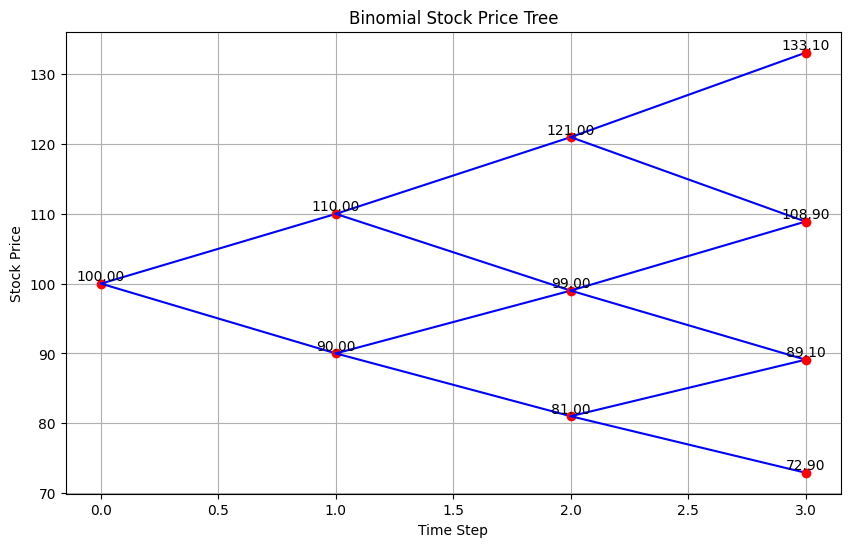

In [4]:
# example that needs to be improved.

def create_binomial_tree(S0, u, d, n):
    """
    Creates a binomial tree for stock prices.

    Args:
        S0 (float): Initial stock price.
        u (float): Upward movement factor.
        d (float): Downward movement factor.
        n (int): Number of time steps.

    Returns:
        numpy.ndarray: A 2D array representing the binomial tree.
    """
    tree = np.zeros((n + 1, n + 1))
    tree[0, 0] = S0

    for i in range(1, n + 1):
        for j in range(i + 1):
            if j == 0:  # All down moves
                tree[i, j] = tree[i - 1, j] * d
            elif j == i:  # All up moves
                tree[i, j] = tree[i - 1, j - 1] * u
            else:  # Mixed moves
                tree[i, j] = tree[i - 1, j - 1] * u # Up path
                # For simplicity in this visualization, we only show one path to each node.
                # In a full binomial model, the node would be reached by either (up, down) or (down, up)
                # and would have the same value.
    return tree

def plot_binomial_tree(tree, n):
    """
    Plots the binomial tree.

    Args:
        tree (numpy.ndarray): The binomial tree data.
        n (int): Number of time steps.
    """
    plt.figure(figsize=(10, 6))
    for i in range(n + 1):
        for j in range(i + 1):
            if i > 0 and j <= i:
                # Plotting connections
                if j < i: # Downward branch
                    plt.plot([i - 1, i], [tree[i-1, j], tree[i, j]], 'b-')
                if j > 0: # Upward branch
                    plt.plot([i - 1, i], [tree[i-1, j-1], tree[i, j]], 'b-')
            # Plotting nodes
            plt.plot(i, tree[i, j], 'ro')
            plt.text(i, tree[i, j], f'{tree[i, j]:.2f}', ha='center', va='bottom')

    plt.title('Binomial Stock Price Tree')
    plt.xlabel('Time Step')
    plt.ylabel('Stock Price')
    plt.grid(True)
    plt.show()

# Parameters for the binomial tree
S0 = 100  # Initial stock price
u = 1.1   # Upward movement factor
d = 0.9   # Downward movement factor
n = 3     # Number of time steps

# Create the binomial tree
stock_tree = create_binomial_tree(S0, u, d, n)
print("Binomial Tree (Stock Prices):")
print(stock_tree)

# Plot the binomial tree
plot_binomial_tree(stock_tree, n)